# MA(q) Parameter Estimation

The moving average model of order $q$, denoted by $\text{MA}(q)$, is defined by,

$
\begin{align}
X_t = \sum_{i=1}^q \vartheta_i \varepsilon_{t-i} + \varepsilon_t
\end{align}
\tag{1}
$

where $\varepsilon_t$ are independent and identically distributed random variables with distribution,

$
\begin{align}
\varepsilon_i \sim \text{Normal}(0, \sigma)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
&\text{E}[\varepsilon_t] = 0 \\
&\text{E}[\varepsilon_t^2] = \sigma^2 \\
&\text{E}[\varepsilon_t \varepsilon_s] = \delta_{ts} \sigma^2
\end{align}
\tag{3}
$

Here the $\vartheta_i$ are estimated given an $MA(q)$ time series. 

## Includes

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def comparison_plot(θ_vals, title, ylim, *params):
    labels = [f"θ={val}" for val in θ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ma_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6), lw=1)
    return t, scan

## Simulations ($\sigma = 1$)

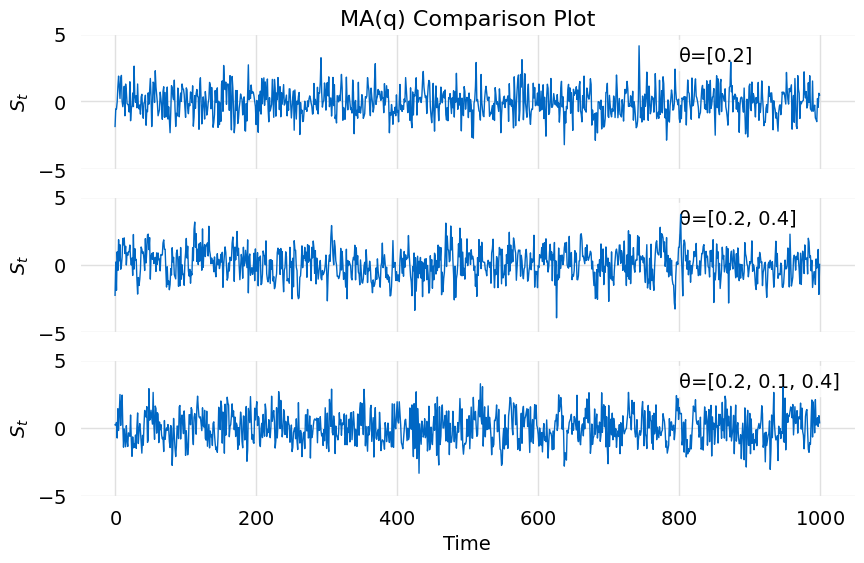

In [3]:
nsample = 1000
σ = 1.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-5.0, 5.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [4]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1424.157
Date:                Fri, 24 Nov 2023   AIC                           2854.314
Time:                        14:01:55   BIC                           2869.038
Sample:                             0   HQIC                          2859.910
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0364      0.038     -0.960      0.337      -0.111       0.038
ma.L1          0.1893      0.033      5.703      0.000       0.124       0.254
sigma2         1.0104      0.044     22.867      0.000       0.924       1.097
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 2.26
Prob(Q):                              0.92   Prob(JB):                         0.32
Heteroskedasticity (H):               0.99   Skew:                             0.10
Prob(H) (two-sided):                  0.96   Kurtosis:                         3.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [5]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.03642238012688515,
      "err": 0.03794029709651492,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "258fae72-aa3d-4903-a846-c0f95769cfba",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.18934003924961323,
         "err": 0.03319820871963378,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "258fae72-aa3d-4903-a846-c0f95769cfba",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 1.0104450711051356,
      "err": 0.04418769619755589,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "25

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [6]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1406.783
Date:                Fri, 24 Nov 2023   AIC                           2821.566
Time:                        14:01:55   BIC                           2841.197
Sample:                             0   HQIC                          2829.027
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0529      0.050      1.062      0.288      -0.045       0.150
ma.L1          0.1895      0.028      6.685      0.000       0.134       0.245
ma.L2          0.4008      0.030     13.493      0.000       0.343       0.459
sigma2         0.9756      0.042     23.114      0.000       0.893       1.058
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 4.07
Prob(Q):                              0.72   Prob(JB):                         0.13
Heteroskedasticity (H):               1.07   Skew:                            -0.14
Prob(H) (two-sided):                  0.51   Kurtosis:                         3.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": 0.05289834060246451,
      "err": 0.049793838834712376,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "eeb12fbd-49c5-477f-b38d-7252af074302",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.18949392038281662,
         "err": 0.028344715290522304,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "eeb12fbd-49c5-477f-b38d-7252af074302",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.40080626336763836,
         "err": 0.029705637214593492,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
   

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [8]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -1431.761
Date:                Fri, 24 Nov 2023   AIC                           2873.522
Time:                        14:01:55   BIC                           2898.060
Sample:                             0   HQIC                          2882.848
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.225e-05      0.057      0.000      1.000      -0.111       0.111
ma.L1          0.2051      0.028      7.401      0.000       0.151       0.259
ma.L2          0.1043      0.029      3.626      0.000       0.048       0.161
ma.L3          0.4598      0.029     15.611      0.000       0.402       0.518
sigma2         1.0252      0.051     20.068      0.000       0.925       1.125
===================================================================================
Ljung-Box (L1) (Q):                   0.45   Jarque-Bera (JB):                 6.41
Prob(Q):                              0.50   Prob(JB):                         0.04
Heteroskedasticity (H):               1.09   Skew:                             0.08
Prob(H) (two-sided):                  0.43   Kurtosis:                         2.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": 1.22542203372302e-05,
      "err": 0.05685629366257049,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "acd1c59c-f204-4b53-9672-e77166cb7dfa",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.20505184960308487,
         "err": 0.027704150310661365,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "acd1c59c-f204-4b53-9672-e77166cb7dfa",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.10430743575763708,
         "err": 0.028769135718442515,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
   

## Simulations ($\sigma = 5$)

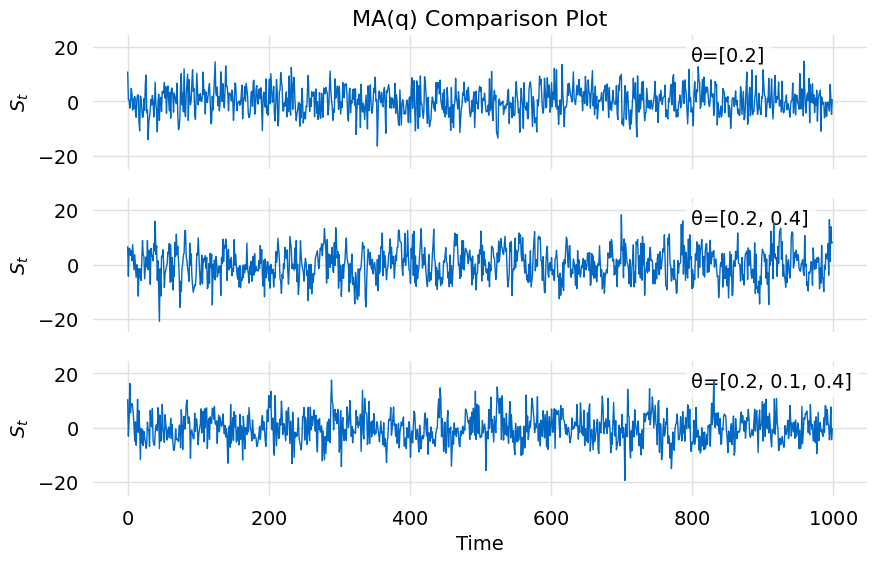

In [10]:
nsample = 1000
σ = 5.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-25.0, 25.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [11]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -2998.783
Date:                Fri, 24 Nov 2023   AIC                           6003.566
Time:                        14:01:55   BIC                           6018.290
Sample:                             0   HQIC                          6009.162
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2972      0.184      1.612      0.107      -0.064       0.659
ma.L1          0.2006      0.031      6.397      0.000       0.139       0.262
sigma2        23.5628      1.067     22.092      0.000      21.472      25.653
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.47
Prob(Q):                              0.85   Prob(JB):                         0.79
Heteroskedasticity (H):               0.91   Skew:                             0.05
Prob(H) (two-sided):                  0.39   Kurtosis:                         2.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": 0.29724799444628397,
      "err": 0.1844443827302876,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "560d0a31-0eae-46ea-8831-f3cfb31b0925",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.20055829118534854,
         "err": 0.03135345746687941,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "560d0a31-0eae-46ea-8831-f3cfb31b0925",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 23.562846587500253,
      "err": 1.066593486024737,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "560d0a

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [13]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -3041.942
Date:                Fri, 24 Nov 2023   AIC                           6091.884
Time:                        14:01:55   BIC                           6111.515
Sample:                             0   HQIC                          6099.345
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1801      0.272      0.663      0.508      -0.353       0.713
ma.L1          0.2189      0.029      7.561      0.000       0.162       0.276
ma.L2          0.4760      0.029     16.276      0.000       0.419       0.533
sigma2        25.6739      1.138     22.568      0.000      23.444      27.904
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 0.70
Prob(Q):                              0.70   Prob(JB):                         0.71
Heteroskedasticity (H):               1.04   Skew:                            -0.06
Prob(H) (two-sided):                  0.72   Kurtosis:                         3.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": 0.1801047331463668,
      "err": 0.27182025854463937,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "c787a40d-bafe-4115-90c6-bfeed2c8ceee",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.21885344572879298,
         "err": 0.028943360110750712,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c787a40d-bafe-4115-90c6-bfeed2c8ceee",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.4759959024989821,
         "err": 0.029244490984697096,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
      

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [15]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -2974.975
Date:                Fri, 24 Nov 2023   AIC                           5959.950
Time:                        14:01:56   BIC                           5984.488
Sample:                             0   HQIC                          5969.276
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1219      0.260     -0.469      0.639      -0.632       0.388
ma.L1          0.2075      0.029      7.272      0.000       0.152       0.263
ma.L2          0.0992      0.030      3.281      0.001       0.040       0.158
ma.L3          0.4241      0.029     14.716      0.000       0.368       0.481
sigma2        22.4535      0.989     22.705      0.000      20.515      24.392
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 0.44
Prob(Q):                              0.79   Prob(JB):                         0.80
Heteroskedasticity (H):               0.99   Skew:                             0.03
Prob(H) (two-sided):                  0.89   Kurtosis:                         3.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "const": {
      "est": -0.12190806249304784,
      "err": 0.2601857899672133,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "450e8ca0-c0ff-458d-a907-960024b3c79e",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.20749239782352422,
         "err": 0.02853216609170098,
         "est_label": "$\\hat{\\theta_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "450e8ca0-c0ff-458d-a907-960024b3c79e",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.09916949796506229,
         "err": 0.030221507583134383,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
     